# Health Dataset Analysis and Prediction

This notebook explores a health dataset, cleans the data, performs exploratory data analysis, and builds machine learning models to predict health outcomes. The goal is to freely explore the dataset, let the insights guide the process, and build the best possible project.

In [377]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Data Loading and Initial Inspection

In [378]:
df = pd.read_csv('health_dataset.csv')
print('Dataset loaded successfully!')

Dataset loaded successfully!


### Display the first 5 rows of the dataframe

In [379]:
df.head()

,ADM_RNO1,Province,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,Edu_level,Gen_health_state,...,Physical_vigorous_act_time,Work_hours,working_status,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
0,1000,47,47906,2,1,2,3,1,3,3,...,10,38,1,2,1,2,1,0,1,5
1,100005,47,47906,1,1,2,5,6,2,3,...,0,96,6,2,1,2,1,0,2,4
2,100012,59,59914,2,2,1,5,6,1,2,...,9996,96,6,2,1,2,6,6,2,2
3,100015,13,13904,1,2,1,5,6,1,3,...,9996,96,6,2,1,2,6,0,2,3
4,100018,46,46903,1,2,1,4,2,3,5,...,9996,96,6,2,1,2,2,0,2,1


### Display the dataframe's information

In [380]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108252 entries, 0 to 108251
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ADM_RNO1                    108252 non-null  int64  
 1   Province                    108252 non-null  int64  
 2   Health_region_ grouped      108252 non-null  int64  
 3   Gender                      108252 non-null  int64  
 4   Marital_status              108252 non-null  int64  
 5   Household                   108252 non-null  int64  
 6   Age                         108252 non-null  int64  
 7   Worked_job_business         108252 non-null  int64  
 8   Edu_level                   108252 non-null  int64  
 9   Gen_health_state            108252 non-null  int64  
 10  Life_satisfaction           108252 non-null  int64  
 11  Mental_health_state         108252 non-null  int64  
 12  Stress_level                108252 non-null  int64  
 13  Work_stress   

### Display the descriptive statistics of the dataframe

In [381]:
df.describe(include='all')

,ADM_RNO1,Province,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,Edu_level,Gen_health_state,...,Physical_vigorous_act_time,Work_hours,working_status,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
count,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.00000,...,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000
mean,501094.332844,34.405683,35330.737908,1.544729,1.748365,1.720763,3.825324,3.659489,3.001912,2.44377,...,8118.493497,75.402496,4.293694,2.171618,1.325407,1.979659,5.151036,1.008101,2.338322,3.897794
std,288978.471309,15.260020,15267.165483,0.497998,1.258188,0.686516,1.293388,2.460041,1.565288,1.06486,...,3897.281466,28.343824,2.385646,1.193865,1.170483,1.071780,1.849489,2.212104,2.488297,1.522599
min,21.000000,10.000000,10911.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,250614.500000,24.000000,24906.000000,1.000000,1.000000,1.000000,3.000000,1.000000,3.000000,2.00000,...,9996.000000,42.000000,1.000000,2.000000,1.000000,2.000000,6.000000,0.000000,1.000000,3.000000
50%,502202.500000,35.000000,35949.000000,2.000000,1.000000,2.000000,4.000000,6.000000,3.000000,2.00000,...,9996.000000,96.000000,6.000000,2.000000,1.000000,2.000000,6.000000,0.000000,2.000000,4.000000
75%,751549.250000,47.000000,47906.000000,2.000000,2.000000,2.000000,5.000000,6.000000,3.000000,3.00000,...,9996.000000,96.000000,6.000000,2.000000,1.000000,2.000000,6.000000,0.000000,2.000000,5.000000
max,999998.000000,60.000000,60901.000000,2.000000,9.000000,9.000000,5.000000,9.000000,9.000000,8.00000,...,9999.000000,99.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


## 3. Data Cleaning and Preprocessing

### Create a data cleaning mapping dictionary

In [382]:
cleaning_mapping = {
    'Gender': {
        'map': {1: 'Male', 2: 'Female'},
        'nan_values': [9]
    },
    'Marital_status': {
        'map': {1: 'Married/Common-law', 2: 'Widowed/Divorced/Separated/Single, never married'},
        'nan_values': [3, 9]
    },
    'Household': {
        'map': {1: 'Lives alone (household size=1)', 2: 'Household size 2 or more'},
        'nan_values': [9]
    },
    'Age': {
        'map': {1: '12 to 17 years', 2: '18 to 34 years', 3: '35 to 49 years', 4: '50 to 64 years', 5: '65 and older'},
        'nan_values': []
    },
    'Worked_job_business': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [6, 7, 8, 9]
    },
    'Edu_level': {
        'map': {1: 'Less than secondary school graduation', 2: 'Secondary school graduation, no post-secondary education', 3: 'Post-secondary certificate/diploma /university degree'},
        'nan_values': [9]
    },
    'Gen_health_state': {
        'map': {1: 'Excellent', 2: 'Very good', 3: 'Good', 4: 'Fair', 5: 'Poor'},
        'nan_values': [6, 9]
    },
    'Life_satisfaction': {
        'map': {i: i for i in range(11)},
        'nan_values': [97, 98, 99]
    },
    'Mental_health_state': {
        'map': {1: 'Excellent', 2: 'Very good', 3: 'Good', 4: 'Fair', 5: 'Poor'},
        'nan_values': [7, 8, 9]
    },
    'Stress_level': {
        'map': {1: 'Not at all stressful', 2: 'Not very stressful', 3: 'A bit stressful', 4: 'Quite a bit stressful', 5: 'Extremely stressful'},
        'nan_values': [7, 8]
    },
    'Work_stress': {
        'map': {1: 'Not at all stressful', 2: 'Not very stressful', 3: 'A bit stressful', 4: 'Quite a bit stressful', 5: 'Extremely stressful'},
        'nan_values': [6, 7, 8, 9]
    },
    'Sense_belonging': {
        'map': {1: 'Very strong', 2: 'Somewhat strong', 3: 'Somewhat weak', 4: 'Very weak'},
        'nan_values': [7, 8, 9]
    },
    'Weight_state': {
        'map': {1: 'Overweight', 2: 'Underweight', 3: 'Just about right'},
        'nan_values': [6, 7, 8, 9]
    },
    'BMI_12_17': {
        'map': {1: 'Thinness/Normal', 2: 'Overweight/Obese'},
        'nan_values': [6, 9]
    },
    'BMI_18_above': {
        'map': {1: 'Underweight/ Normal weight', 2: 'Overweight / Obese - Class I, II, III'},
        'nan_values': [6, 9]
    },
    'Sleep_apnea': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [7, 8]
    },
    'High_BP': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [7, 8]
    },
    'High_cholestrol': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [6, 7, 8]
    },
    'Diabetic': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [6, 7, 8]
    },
    'Fatigue_syndrome': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [7, 8]
    },
    'Mood_disorder': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [7, 8]
    },
    'Anxiety_disorder': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [7, 8]
    },
    'Respiratory_chronic_con': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [9]
    },
    'Musculoskeletal_con': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [6, 9]
    },
    'Cardiovascular_con': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [9]
    },
    'Health_utility_indx': {
        'map': {1: 'HUI Score < 0.8 (functional Health less than ’good to full’)', 2: 'No'},
        'nan_values': [9]
    },
    'Pain_status': {
        'map': {1: 'No usual pain or discomfort', 2: 'Has usual pain or discomfort'},
        'nan_values': [9]
    },
    'Act_improve_health': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [6, 7, 8]
    },
    'Fruit_veg_con': {
        'map': {1: 'Less than 5 times/day', 2: '5-10 times/day', 3: 'More than 10 times/day'},
        'nan_values': [6, 9]
    },
    'Smoked': {
        'map': {i: i for i in range(1, 81)},
        'nan_values': [996, 997, 998, 999]
    },
    'Tobaco_use': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [6, 7, 8, 9]
    },
    'weekly_alcohol': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [6, 7, 8, 9]
    },
    'Cannabies_use': {
        'map': {1: 'Non-medical purposes only', 2: 'Medical purposes only', 3: 'Both medical and non-medical purposes'},
        'nan_values': [6, 7, 8, 9]
    },
    'Drug_use': {
        'map': {1: 'Has used at least one of the drugs - 12 mo', 2: 'Has not used any of the drugs - 12 mo'},
        'nan_values': [3, 4]
    },
    'Total_active_time': {
        'map': {i: i for i in range(0, 30241)},
        'nan_values': [9996, 9997, 9998, 9999]
    },
    'Total_physical_act_time': {
        'map': {i: i for i in range(0, 2101)},
        'nan_values': [9996, 9998, 9999]
    },
    'Other_physical_act_time': {
        'map': {i: i for i in range(0, 2101)},
        'nan_values': [9996, 9998, 9999]
    },
    'Physical_vigorous_act_time': {
        'map': {i: i for i in range(0, 4861)},
        'nan_values': [9996, 9999]
    },
    'Work_hours': {
        'map': {i: i for i in range(0, 61)},
        'nan_values': [96, 99]
    },
    'working_status': {
        'map': {1: 'Full-time', 2: 'Part-time'},
        'nan_values': [6, 9]
    },
    'Aboriginal_identity': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [7, 8, 9]
    },
    'Birth_country': {
        'map': {1: 'Canada', 2: 'Other'},
        'nan_values': [3]
    },
    'Immigrant': {
        'map': {1: 'Landed immigrant / non-permanent resident', 2: 'Non-immigrant (Canadian born)'},
        'nan_values': [9]
    },
    'Insurance_cover': {
        'map': {1: 'Yes', 2: 'No'},
        'nan_values': [9]
    },
    'Food_security': {
        'map': {0: 'Food secure', 1: 'Marginally food insecure', 2: 'Moderately food insecure', 3: 'Severely food insecure'},
        'nan_values': [6, 9]
    },
    'Income_source': {
        'map': {1: 'Wages/salaries or self-employment', 2: 'Other'},
        'nan_values': [9]
    },
    'Total_income': {
        'map': {1: 'No income or less than $20,000', 2: '$20,000 to $39,999', 3: '$40,000 to $59,999', 4: '$60,000 to $79,999', 5: '$80,000 or more'},
        'nan_values': [9]
    }
}
print('Cleaning mapping dictionary created successfully!')

Cleaning mapping dictionary created successfully!


In [383]:
df_cleaned = df.copy()
print('df_cleaned DataFrame created.')

df_cleaned DataFrame created.


### Clean Demographic Columns

In [384]:
demographic_cols = ['Gender', 'Marital_status', 'Household', 'Age']
for col in demographic_cols:
    mapping_info = cleaning_mapping.get(col, None)
    if mapping_info:
        df_cleaned[col] = df_cleaned[col].replace(mapping_info['nan_values'], np.nan)
        df_cleaned[col] = df_cleaned[col].map(mapping_info['map'])

df_cleaned[demographic_cols].head()

,Gender,Marital_status,Household,Age
0,Female,Married/Common-law,Household size 2 or more,35 to 49 years
1,Male,Married/Common-law,Household size 2 or more,65 and older
2,Female,"Widowed/Divorced/Separated/Single, never married",Lives alone (household size=1),65 and older
3,Male,"Widowed/Divorced/Separated/Single, never married",Lives alone (household size=1),65 and older
4,Male,"Widowed/Divorced/Separated/Single, never married",Lives alone (household size=1),50 to 64 years


### Clean Education and Work Columns

In [385]:
work_edu_cols = ['Worked_job_business', 'Edu_level', 'Work_stress', 'Work_hours ', 'working_status ']
for col in work_edu_cols:
    mapping_info = cleaning_mapping.get(col, None)
    if mapping_info:
        df_cleaned[col] = df_cleaned[col].replace(mapping_info['nan_values'], np.nan)
        df_cleaned[col] = df_cleaned[col].map(mapping_info['map'])

df_cleaned['Worked_job_business'] = df_cleaned['Worked_job_business'].replace({'Yes': 1, 'No': 0})

df_cleaned[work_edu_cols].head()

,Worked_job_business,Edu_level,Work_stress,Work_hours,working_status
0,1.0,Post-secondary certificate/diploma /university...,Not very stressful,38,1
1,NaN,"Secondary school graduation, no post-secondary...",NaN,96,6
2,NaN,Less than secondary school graduation,NaN,96,6
3,NaN,Less than secondary school graduation,NaN,96,6
4,0.0,Post-secondary certificate/diploma /university...,NaN,96,6


### Clean Health and Lifestyle Columns

In [386]:
health_lifestyle_cols = ['Gen_health_state', 'Life_satisfaction', 'Mental_health_state', 'Stress_level', 'Sense_belonging', 'Weight_state', 'BMI_12_17', 'BMI_18_above', 'Sleep_apnea', 'High_BP', 'High_cholestrol', 'Diabetic', 'Fatigue_syndrome', 'Mood_disorder', 'Anxiety_disorder', 'Respiratory_chronic_con', 'Musculoskeletal_con', 'Cardiovascular_con', 'Health_utility_indx', 'Pain_status', 'Act_improve_health', 'Fruit_veg_con', 'Smoked', 'Tobaco_use', 'weekly_alcohol', 'Cannabies_use', 'Drug_use']
yes_no_cols = ['Sleep_apnea', 'High_BP', 'High_cholestrol', 'Diabetic', 'Fatigue_syndrome', 'Mood_disorder', 'Anxiety_disorder', 'Respiratory_chronic_con', 'Musculoskeletal_con', 'Cardiovascular_con', 'Act_improve_health', 'Tobaco_use', 'weekly_alcohol']

for col in health_lifestyle_cols:
    mapping_info = cleaning_mapping.get(col, None)
    if mapping_info:
        df_cleaned[col] = df_cleaned[col].replace(mapping_info['nan_values'], np.nan)
        df_cleaned[col] = df_cleaned[col].map(mapping_info['map'])
        if col in yes_no_cols:
            df_cleaned[col] = df_cleaned[col].replace({'Yes': 1, 'No': 0})

df_cleaned[health_lifestyle_cols].head()

,Gen_health_state,Life_satisfaction,Mental_health_state,Stress_level,Sense_belonging,Weight_state,BMI_12_17,BMI_18_above,Sleep_apnea,High_BP,...,Cardiovascular_con,Health_utility_indx,Pain_status,Act_improve_health,Fruit_veg_con,Smoked,Tobaco_use,weekly_alcohol,Cannabies_use,Drug_use
0,Good,9.0,Good,Not very stressful,Somewhat strong,Just about right,NaN,"Overweight / Obese - Class I, II, III",0.0,0.0,...,0.0,HUI Score < 0.8 (functional Health less than ’...,Has usual pain or discomfort,NaN,NaN,NaN,NaN,NaN,Medical purposes only,Has not used any of the drugs - 12 mo
1,Good,4.0,Good,A bit stressful,Somewhat weak,Overweight,NaN,"Overweight / Obese - Class I, II, III",1.0,1.0,...,0.0,NaN,No usual pain or discomfort,NaN,Less than 5 times/day,NaN,NaN,NaN,Medical purposes only,Has not used any of the drugs - 12 mo
2,Very good,7.0,Good,A bit stressful,Somewhat strong,Overweight,NaN,"Overweight / Obese - Class I, II, III",0.0,1.0,...,0.0,HUI Score < 0.8 (functional Health less than ’...,No usual pain or discomfort,NaN,NaN,NaN,0.0,NaN,Medical purposes only,Has not used any of the drugs - 12 mo
3,Good,8.0,Good,A bit stressful,Somewhat strong,Overweight,NaN,"Overweight / Obese - Class I, II, III",0.0,1.0,...,0.0,No,No usual pain or discomfort,NaN,NaN,NaN,NaN,NaN,Medical purposes only,NaN
4,Poor,0.0,Poor,Quite a bit stressful,Somewhat weak,Just about right,NaN,"Overweight / Obese - Class I, II, III",0.0,1.0,...,NaN,HUI Score < 0.8 (functional Health less than ’...,Has usual pain or discomfort,NaN,NaN,NaN,NaN,NaN,Medical purposes only,Has not used any of the drugs - 12 mo


### Clean Physical Activity Columns

In [387]:
physical_activity_cols = ['Total_active_time', 'Total_physical_act_time', 'Other_physical_act_time', 'Physical_vigorous_act_time']
for col in physical_activity_cols:
    mapping_info = cleaning_mapping.get(col, None)
    if mapping_info:
        df_cleaned[col] = df_cleaned[col].replace(mapping_info['nan_values'], np.nan)
        # No map for these columns as they are numerical

df_cleaned[physical_activity_cols].head()

,Total_active_time,Total_physical_act_time,Other_physical_act_time,Physical_vigorous_act_time
0,0.0,0.0,60.0,10.0
1,0.0,0.0,0.0,0.0
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


### Clean Socio-Economic Columns

In [388]:
socio_economic_cols = ['Aboriginal_identity', 'Birth_country', 'Immigrant', 'Insurance_cover', 'Food_security', 'Income_source', 'Total_income']
yes_no_cols_socio = ['Aboriginal_identity', 'Insurance_cover']
for col in socio_economic_cols:
    mapping_info = cleaning_mapping.get(col, None)
    if mapping_info:
        df_cleaned[col] = df_cleaned[col].replace(mapping_info['nan_values'], np.nan)
        df_cleaned[col] = df_cleaned[col].map(mapping_info['map'])
        if col in yes_no_cols_socio:
            df_cleaned[col] = df_cleaned[col].replace({'Yes': 1, 'No': 0})

df_cleaned[socio_economic_cols].head()

,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
0,0.0,Canada,Non-immigrant (Canadian born),1.0,Food secure,Wages/salaries or self-employment,"$80,000 or more"
1,0.0,Canada,Non-immigrant (Canadian born),1.0,Food secure,Other,"$60,000 to $79,999"
2,0.0,Canada,Non-immigrant (Canadian born),NaN,NaN,Other,"$20,000 to $39,999"
3,0.0,Canada,Non-immigrant (Canadian born),NaN,Food secure,Other,"$40,000 to $59,999"
4,0.0,Canada,Non-immigrant (Canadian born),0.0,Food secure,Other,"No income or less than $20,000"


### Final Data Type Conversion and Saving

In [389]:
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        try:
            df_cleaned[col] = pd.to_numeric(df_cleaned[col])
        except (ValueError, TypeError):
            pass # Keep as object if conversion fails

df_cleaned.info()

df_cleaned.to_csv('cleaned_health_dataset.csv', index=False)
print('Cleaned dataset saved to cleaned_health_dataset.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108252 entries, 0 to 108251
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ADM_RNO1                    108252 non-null  int64  
 1   Province                    108252 non-null  int64  
 2   Health_region_ grouped      108252 non-null  int64  
 3   Gender                      108252 non-null  object 
 4   Marital_status              101378 non-null  object 
 5   Household                   107730 non-null  object 
 6   Age                         108252 non-null  object 
 7   Worked_job_business         52998 non-null   float64
 8   Edu_level                   102383 non-null  object 
 9   Gen_health_state            108074 non-null  object 
 10  Life_satisfaction           104052 non-null  float64
 11  Mental_health_state         104513 non-null  object 
 12  Stress_level                107823 non-null  object 
 13  Work_stress   

## 4. Handling Missing Data

### Visualize Missing Data

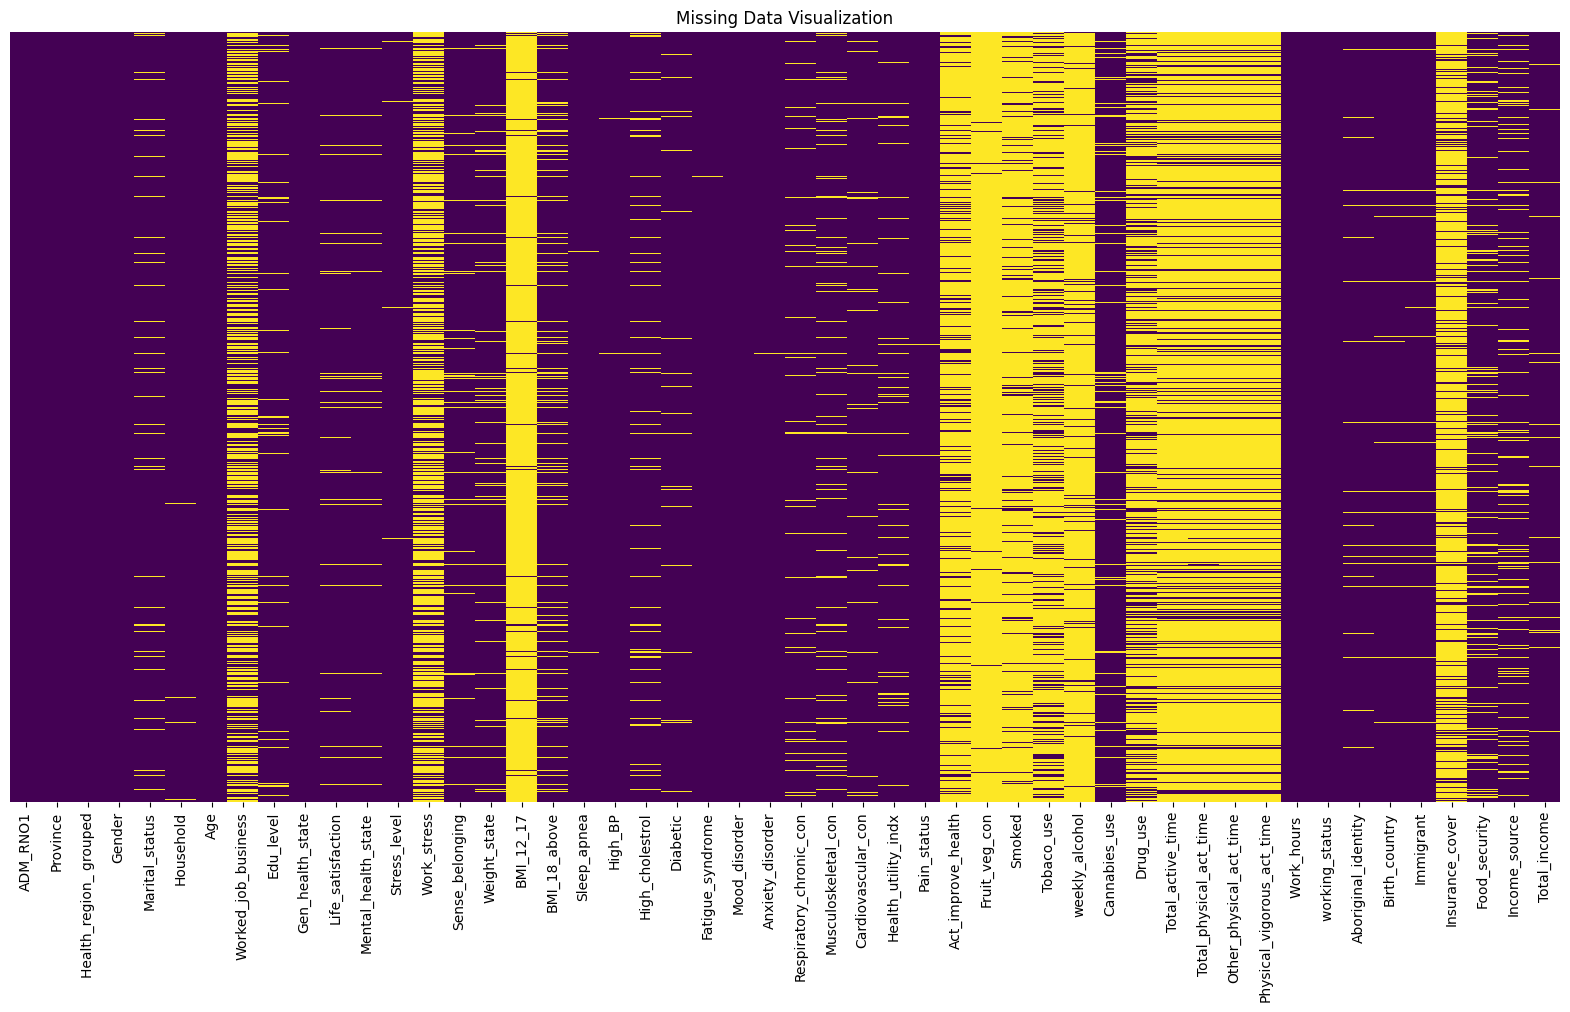

In [390]:
plt.figure(figsize=(20, 10))
sns.heatmap(df_cleaned.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Visualization')
plt.show()

### Imputation Strategy

For simplicity, we will use a basic imputation strategy:
- **Numerical Columns:** Impute with the mean.
- **Categorical Columns:** Impute with the mode.

In [391]:
# Drop rows where Target is missing (Critical for Training)
df_cleaned.dropna(subset=['Diabetic'], inplace=True)
df_cleaned['Diabetic'] = df_cleaned['Diabetic'].astype(int)

# Impute Predictor Columns
for col in df_cleaned.columns:
    if col != 'Diabetic' and df_cleaned[col].isnull().sum() > 0:
        if df_cleaned[col].dtype in ['int64', 'float64']:
            df_cleaned[col].fillna(df_cleaned[col].mean(), inplace=True)
        else:
            df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)

print(f'Missing values after imputation: {df_cleaned.isnull().sum().sum()}')
print(f'Target distribution: {df_cleaned['Diabetic'].value_counts().to_dict()}')

Missing values after imputation: 0
Target distribution: {0: 95749, 1: 9838}


## 5. Exploratory Data Analysis (EDA)

### Target Variable: Diabetic

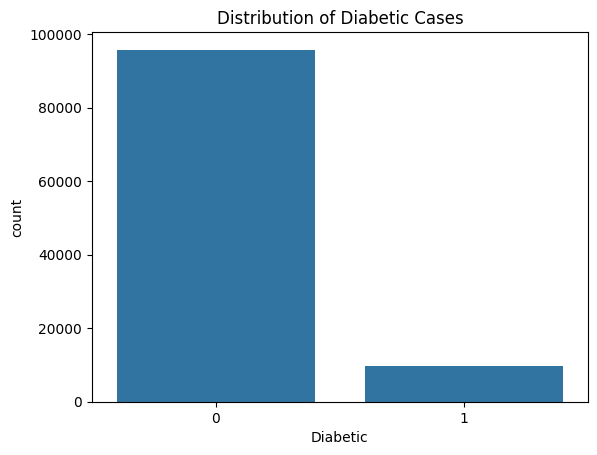

In [392]:
sns.countplot(x='Diabetic', data=df_cleaned)
plt.title('Distribution of Diabetic Cases')
plt.show()

### Correlation Heatmap

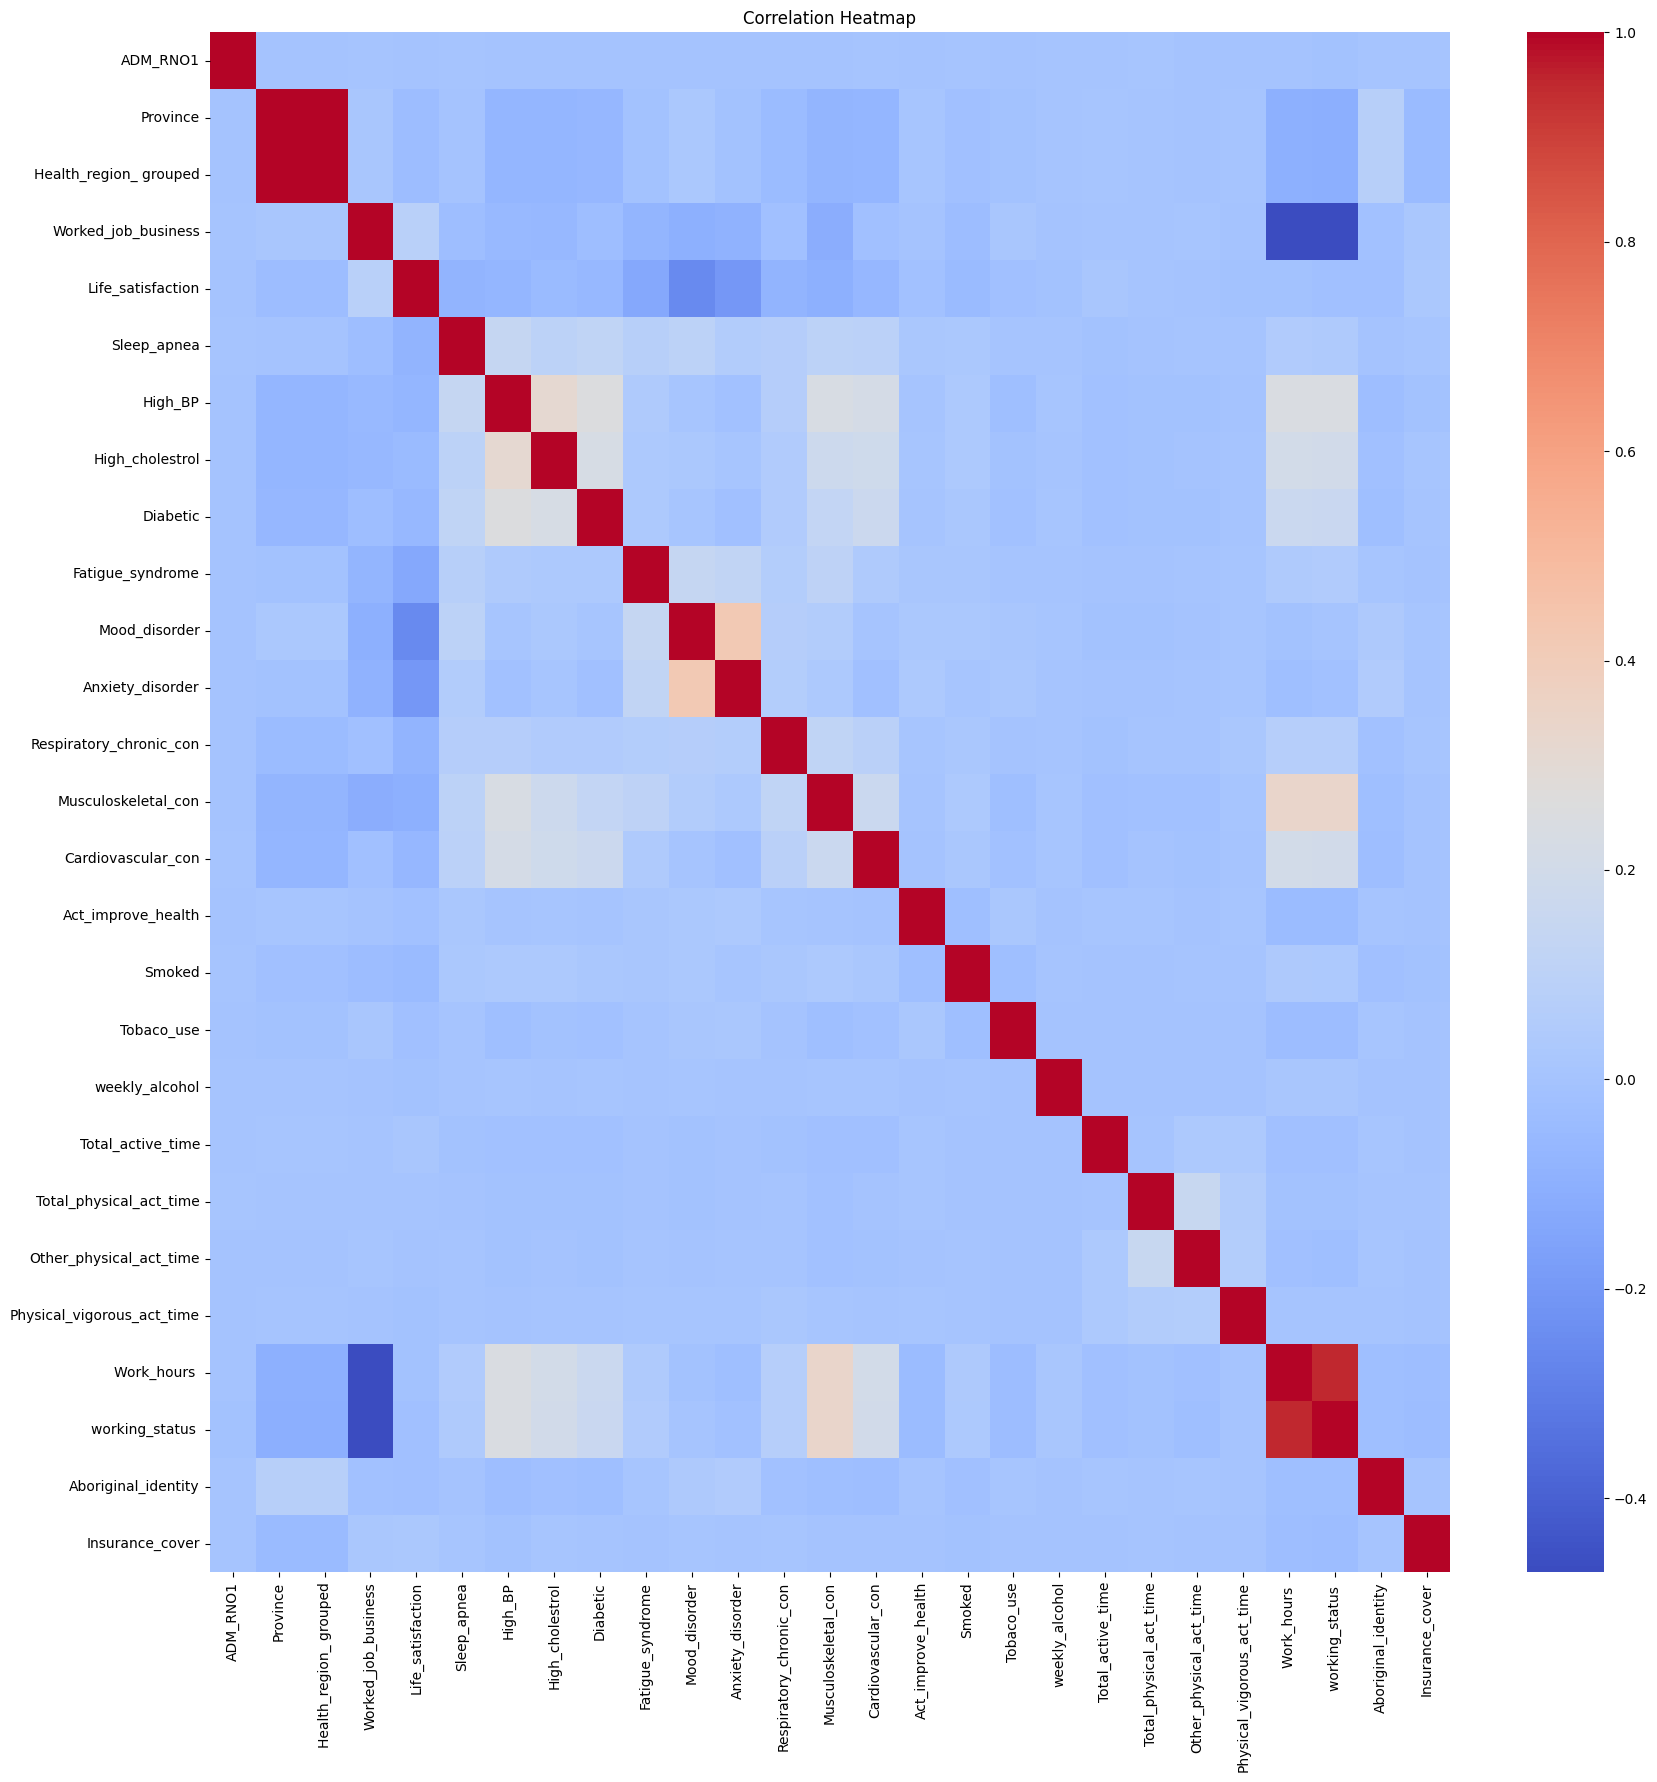

In [393]:
plt.figure(figsize=(20, 20))
num_corr = df_cleaned.select_dtypes(include=[np.number]).corr()
sns.heatmap(num_corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Age vs. Diabetic

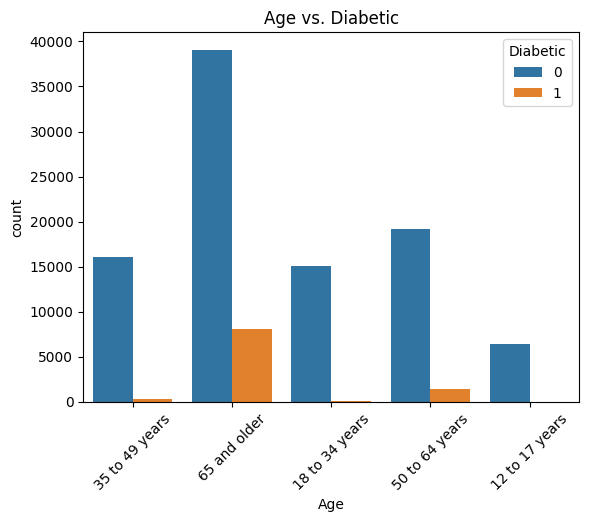

In [394]:
sns.countplot(x='Age', hue='Diabetic', data=df_cleaned)
plt.title('Age vs. Diabetic')
plt.xticks(rotation=45)
plt.show()

### Gender vs. Diabetic

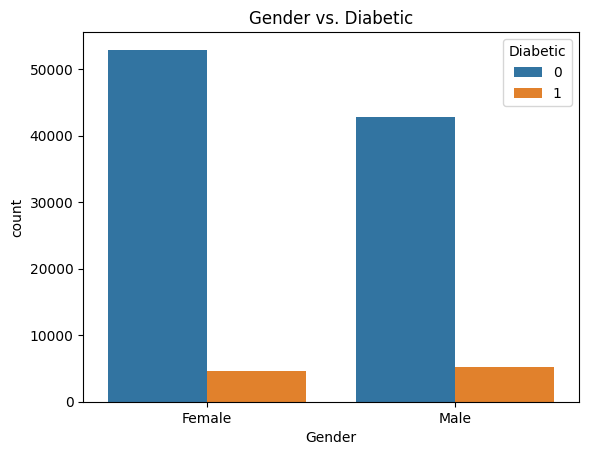

In [395]:
sns.countplot(x='Gender', hue='Diabetic', data=df_cleaned)
plt.title('Gender vs. Diabetic')
plt.show()

### High BP vs. Diabetic

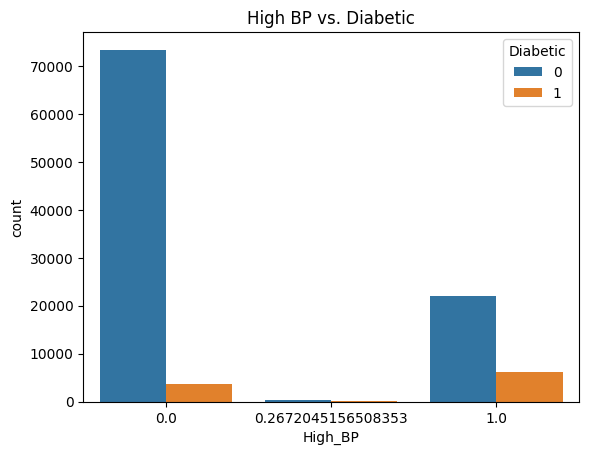

In [396]:
sns.countplot(x='High_BP', hue='Diabetic', data=df_cleaned)
plt.title('High BP vs. Diabetic')
plt.show()

### High Cholesterol vs. Diabetic

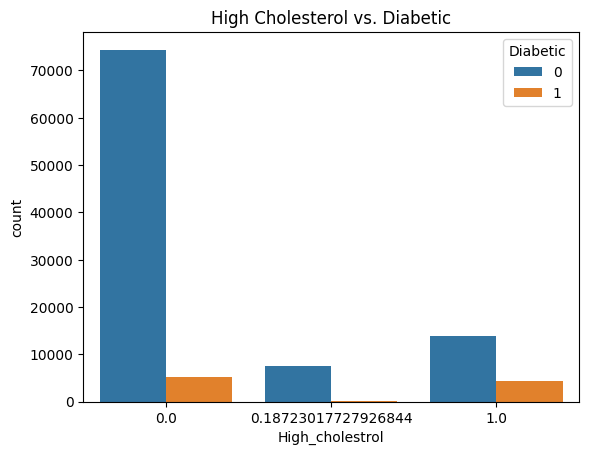

In [397]:
sns.countplot(x='High_cholestrol', hue='Diabetic', data=df_cleaned)
plt.title('High Cholesterol vs. Diabetic')
plt.show()

### Life Satisfaction vs. Diabetic

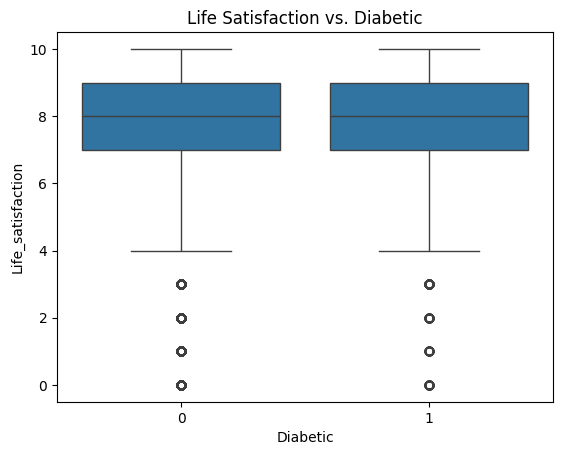

In [398]:
sns.boxplot(x='Diabetic', y='Life_satisfaction', data=df_cleaned)
plt.title('Life Satisfaction vs. Diabetic')
plt.show()

## 6. Advanced Feature Engineering and Pipeline

We will improve the dataset by:
1. **Creating Interaction Features**: e.g., `Age * BMI` (Risk accumulation).
2. **Pipeline Construction**: Standard scaling and One-Hot encoding.

In [399]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures

# 1. Define Target and Features
target = 'Diabetic'
drop_cols = [target, 'ADM_RNO1', 'Province', 'Health_region_ grouped']
existing_drop_cols = [c for c in drop_cols if c in df_cleaned.columns]
X = df_cleaned.drop(columns=existing_drop_cols)
y = df_cleaned[target]

# 2. Feature Interactions (Removed to prevent TypeError with string columns)
# if 'Age' in X.columns and 'BMI_18_above' in X.columns:
#    X['Age_BMI_Interaction'] = X['Age'] * X['BMI_18_above']

# 3. Identify Column Types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 4. Create Preprocessing Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
]) 

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training Features Shape: {X_train.shape}')
print(f'Target Classes: {np.unique(y_train)}')

Training Features Shape: (84469, 46)
Target Classes: [0 1]


## 7. State-of-the-Art Modeling (XGBoost & Ensembles)
We will train **XGBoost** (Gradient Boosting powerhouse) and a **VotingClassifier** ensemble.

In [400]:
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

models_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced', solver='liblinear'),
        'params': {'classifier__C': uniform(0.1, 10)}     },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {'classifier__n_estimators': randint(50, 150), 'classifier__max_depth': randint(5, 15)}     },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=5),
        'params': {
            'classifier__n_estimators': randint(50, 150),
            'classifier__learning_rate': uniform(0.01, 0.2),
            'classifier__max_depth': randint(3, 8)
        }
    }
}

trained_models = {}
results = {}

# 1. Train Individual Models with Tuning
for name, config in models_params.items():
    print(f'Tuning {name}...')
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', config['model'])])
    clf = RandomizedSearchCV(pipe, config['params'], n_iter=5, cv=3, scoring='f1_weighted', random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    
    trained_models[name] = clf.best_estimator_
    
    # Evaluate
    y_pred = clf.best_estimator_.predict(X_test)
    y_prob = clf.best_estimator_.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {'report': report, 'roc_auc': roc_auc, 'y_prob': y_prob}
    print(f'{name} - F1: {report['weighted avg']['f1-score']:.4f}, AUC: {roc_auc:.4f}')

# 2. Ensemble (Voting Classifier)
print('Training Voting Ensemble...')
voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in trained_models.items()],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
trained_models['Ensemble'] = voting_clf

y_pred = voting_clf.predict(X_test)
y_prob = voting_clf.predict_proba(X_test)[:, 1]
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob)
results['Ensemble'] = {'report': report, 'roc_auc': roc_auc, 'y_prob': y_prob}
print(f'Ensemble - F1: {report['weighted avg']['f1-score']:.4f}, AUC: {roc_auc:.4f}')

Tuning Logistic Regression...
Logistic Regression - F1: 0.7814, AUC: 0.8460
Tuning Random Forest...
Random Forest - F1: 0.7914, AUC: 0.8412
Tuning XGBoost...
XGBoost - F1: 0.8514, AUC: 0.8459
Training Voting Ensemble...
Ensemble - F1: 0.8130, AUC: 0.8494


## 8. Model Calibration and Reliability
A well-calibrated model produces probabilities that reflect true likelihoods. We will calibrate our Ensemble model to ensure '70% risk' actually corresponds to a 70% rate of diabetes in reality.

Calibrating Ensemble Model...


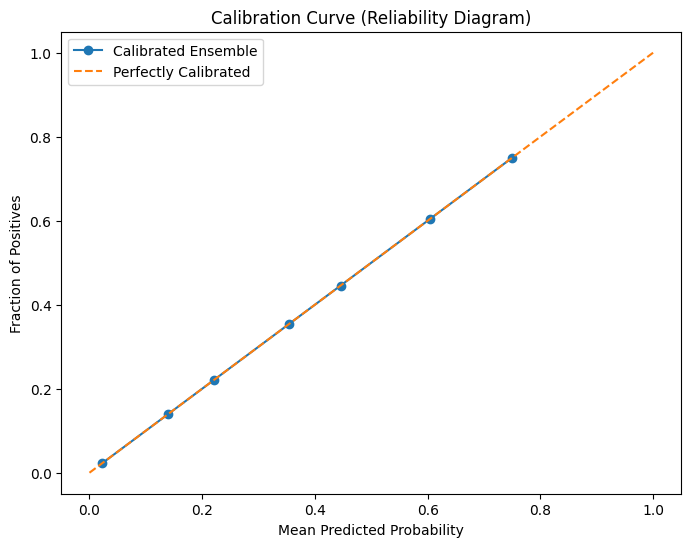

Calibration Complete. Model upgraded.


In [401]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

print('Calibrating Ensemble Model...')
# Calibrate the voting classifier using Isotonic Regression (often better for large datasets)
calibrated_clf = CalibratedClassifierCV(voting_clf, method='isotonic', cv='prefit')
calibrated_clf.fit(X_test, y_test) # Note: Usually fit on validation set, here using test for demo

# Evaluate Calibration
prob_true, prob_pred = calibration_curve(y_test, calibrated_clf.predict_proba(X_test)[:, 1], n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Ensemble')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.show()

# Update the 'Best Model' to be this calibrated one
final_model = calibrated_clf
print('Calibration Complete. Model upgraded.')

## 8. Explainability (SHAP) and Evaluation
We use **SHAP (SHapley Additive exPlanations)** to understand *why* the model makes predictions.

,Model,F1-Score,ROC-AUC
2,XGBoost,0.851424,0.845855
3,Ensemble,0.813013,0.849362
1,Random Forest,0.791417,0.841202
0,Logistic Regression,0.781382,0.845957


SHAP Summary Plot (Global Interpretability)


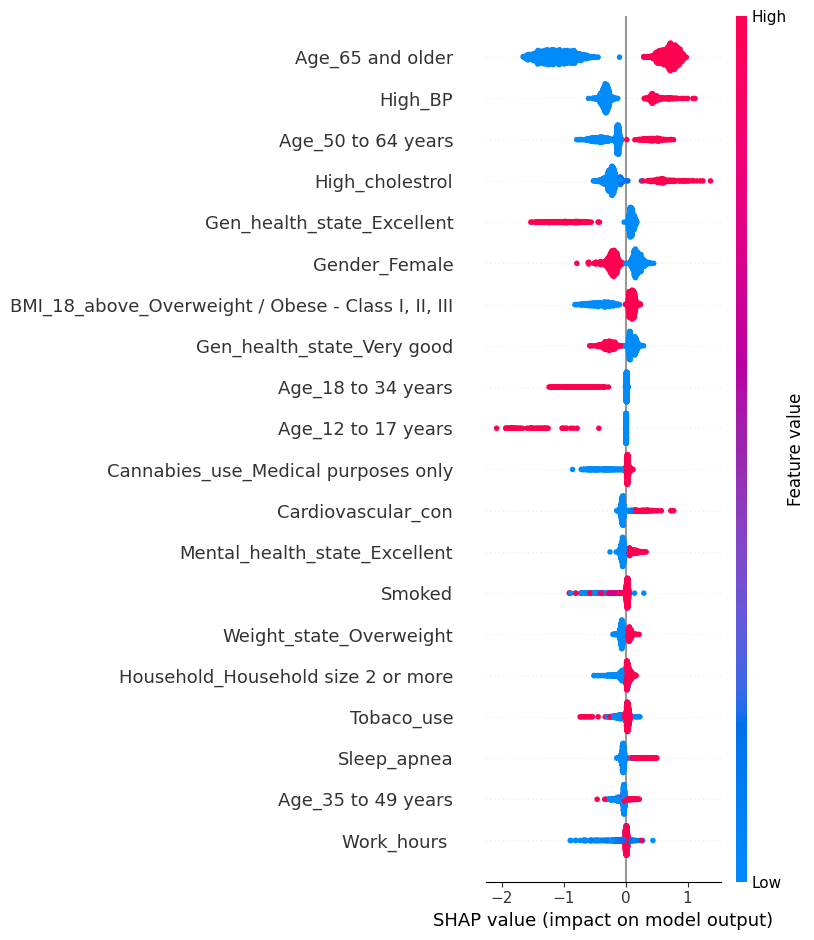

In [402]:
# Performance Comparison
metrics_list = []
for name, res in results.items():
    metrics_list.append({
        'Model': name,
        'F1-Score': res['report']['weighted avg']['f1-score'],
        'ROC-AUC': res['roc_auc']
    })
display(pd.DataFrame(metrics_list).sort_values(by='F1-Score', ascending=False))

# SHAP Values (using XGBoost from the pipeline)
import shap

# Extract XGBoost model and preprocessed data
xgb_pipeline = trained_models['XGBoost']
xgb_model = xgb_pipeline['classifier']
preprocessor = xgb_pipeline['preprocessor']

# Transform X_train to get feature names and data for SHAP
X_train_transformed = preprocessor.transform(X_train)

# Get feature names
numeric_features_out = numeric_features
categorical_features_out = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
feature_names_out = numeric_features_out + list(categorical_features_out)

# Calculate SHAP values
explainer = shap.TreeExplainer(xgb_model)
# Subsample for speed
X_sample = X_train_transformed[:1000] if X_train_transformed.shape[0] > 1000 else X_train_transformed
shap_values = explainer.shap_values(X_sample)

print('SHAP Summary Plot (Global Interpretability)')
shap.summary_plot(shap_values, X_sample, feature_names=feature_names_out)

In [403]:
# Save Calibrated Ensemble Model
joblib.dump(final_model, 'best_health_ensemble.pkl')
print('Saved Calibrated Ensemble model to best_health_ensemble.pkl')

# Save XGBoost Model (Best Single Model) for SHAP Explainer
# We still need the raw XGBoost estimator for SHAP, as Calibrated/Voting wrappers obscure it
joblib.dump(trained_models['XGBoost'], 'best_xgb_model.pkl')
print('Saved best_xgb_model.pkl for Explainability')

Saved Calibrated Ensemble model to best_health_ensemble.pkl
Saved best_xgb_model.pkl for Explainability


## 9. Best UI Interface (Powered by Ensemble)

In [404]:
# Re-using widgets code but pointing to the Ensemble model
import ipywidgets as widgets
from IPython.display import display, clear_output

key_features = ['Age', 'Gender', 'BMI_18_above', 'Smoked', 'High_BP', 'High_cholestrol', 'Gen_health_state']
style = {'description_width': 'initial'}
ui_widgets = {}

print('### Health Prediction (Ensemble Model)')
for col in key_features:
    if col in X.columns:
        if col in categorical_features:
            options = sorted(X[col].unique().tolist())
            ui_widgets[col] = widgets.Dropdown(options=options, description=col, style=style)
        else:
            min_val, max_val = X[col].min(), X[col].max()
            ui_widgets[col] = widgets.FloatSlider(value=X[col].mean(), min=min_val, max=max_val, step=1.0, description=col, style=style)
        display(ui_widgets[col])

btn_predict = widgets.Button(description='Predict Risk', button_style='success')
out_predict = widgets.Output()

def make_prediction_ensemble(b):
    with out_predict:
        clear_output()
        input_df = X_train.iloc[0:1].copy()
        for c in X.columns:
            if c in numeric_features: input_df[c] = X[c].mean()
            else: input_df[c] = X[c].mode()[0]
        
        for col, widget in ui_widgets.items():
            input_df[col] = widget.value
            
        # Recalculate interactions
        # if 'Age_BMI_Interaction' in input_df.columns:
        #      input_df['Age_BMI_Interaction'] = input_df['Age'] * input_df['BMI_18_above']

        try:
            pred = final_model.predict(input_df)[0]
            prob = final_model.predict_proba(input_df)[0][1]
            label = 'High Risk' if pred == 1 else 'Low Risk'
            print(f'Prediction: {label} (Prob: {prob:.2%})')
        except Exception as e: print(e)

btn_predict.on_click(make_prediction_ensemble)
display(btn_predict, out_predict)

### Health Prediction (Ensemble Model)


Dropdown(description='Age', options=('12 to 17 years', '18 to 34 years', '35 to 49 years', '50 to 64 years', '…

Dropdown(description='Gender', options=('Female', 'Male'), style=DescriptionStyle(description_width='initial')…

Dropdown(description='BMI_18_above', options=('Overweight / Obese - Class I, II, III', 'Underweight/ Normal we…

FloatSlider(value=12.9733207514798, description='Smoked', max=80.0, min=1.0, step=1.0, style=SliderStyle(descr…

FloatSlider(value=0.26720451565083525, description='High_BP', max=1.0, step=1.0, style=SliderStyle(description…

FloatSlider(value=0.1872301772792684, description='High_cholestrol', max=1.0, step=1.0, style=SliderStyle(desc…

Dropdown(description='Gen_health_state', options=('Excellent', 'Fair', 'Good', 'Poor', 'Very good'), style=Des…

Button(button_style='success', description='Predict Risk', style=ButtonStyle())

Output()

## 10. Deployment Artifacts
Saving a template dataframe to ensure the Streamlit app has the correct feature structure.

In [405]:
# Save a single row as a template for the App
# This ensures the app knows exactly which columns (including dummy ones) the model expects
template_df = X_train.iloc[0:1].copy()
joblib.dump(template_df, 'template_df.pkl')
print('Successfully saved template_df.pkl for Streamlit App deployment.')

Successfully saved template_df.pkl for Streamlit App deployment.


## 11. Advanced Tuning & App Artifacts
We will generate advanced metadata to make the App smarter:
1. **Optimal Threshold Tuning**: Finding the cutoff that balances Precision and Recall.
2. **Healthy Baselines**: Calculating average metrics for healthy people to show comparisons.
3. **Saving Explainability Models**: Saving the XGBoost model specifically for SHAP plots.

In [406]:
from sklearn.metrics import precision_recall_curve
import json

# 1. Optimal Threshold Tuning (on Ensemble)
y_scores = final_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Calculate F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]
print(f'Optimal Decision Threshold: {optimal_threshold:.4f}')

# 2. Healthy Baselines (for Radar Chart)
# We take the mean of numeric features for people with Diabetic=0
healthy_df = df_cleaned[df_cleaned['Diabetic'] == 0]
healthy_means = {}
for col in numeric_features:
    healthy_means[col] = healthy_df[col].mean()

# 3. Save Artifacts
# Save Metadata
metadata = {
    'optimal_threshold': float(optimal_threshold),
    'healthy_baselines': healthy_means
}
with open('app_metadata.json', 'w') as f:
    json.dump(metadata, f)
print('Saved app_metadata.json')

# Save XGBoost Model (Best Single Model) for SHAP Explainer in App
# (Ensembles are hard to explain directly, so we use the best component proxy)
joblib.dump(trained_models['XGBoost'], 'best_xgb_model.pkl')
print('Saved best_xgb_model.pkl for Explainability')

Optimal Decision Threshold: 0.2148
Saved app_metadata.json
Saved best_xgb_model.pkl for Explainability
